In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

# 0- Data Preparation

In [2]:
from src.data_loader import RottenTomatoesDataLoader

from src.baselines import MajorityClassBaseline
from src.evaluation import evaluate_classifier, plot_confusion_matrix

import matplotlib.pyplot as plt
import pandas as pd


/home/alireza/Work/llm-text-classification-benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the Rotten Tomatoes dataset using the data_loader from the src
loader = RottenTomatoesDataLoader()

dataset = loader.load_dataset_local()

2026-07-06 19:18:38,370 - INFO - Loading dataset from local_path: /home/alireza/Work/llm-text-classification-benchmark/data/raw/rotten_tomatoes


In [4]:
# Create train, validation, and test splits
train_ds = dataset["train"]
validation_ds = dataset["validation"]
test_ds = dataset["test"]

# Convert to pands DataFrames
train_df = train_ds.to_pandas()
validation_df = validation_ds.to_pandas()
test_df = test_ds.to_pandas()

print(f"Train dataset shape: {train_df.shape}")
print(f"Validation dataset shape: {validation_df.shape}")
print(f"Test dataset shape: {test_df.shape}")

Train dataset shape: (8530, 2)
Validation dataset shape: (1066, 2)
Test dataset shape: (1066, 2)


In [5]:
# Display class distribution for each split
for split_name, split_df in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df
}.items():

    print(f"{split_name.capitalize()} dataset class distribution: \n\n{split_df['label'].value_counts(normalize=True)}\n")

Train dataset class distribution: 

label
1    0.5
0    0.5
Name: proportion, dtype: float64

Validation dataset class distribution: 

label
1    0.5
0    0.5
Name: proportion, dtype: float64

Test dataset class distribution: 

label
1    0.5
0    0.5
Name: proportion, dtype: float64



# 1- Train and evaluate the majority class baseline model

In [6]:
# Seprate features and labels for each split
X_train, y_train = train_df["text"], train_df["label"]

X_test, y_test = test_df["text"], test_df["label"]


In [7]:
# Train the Majority Class Baseline model
baseline = MajorityClassBaseline()
baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)

Baseline Model Metrics:
accuracy: 0.50
precision: 0.00
recall: 0.00
f1: 0.00


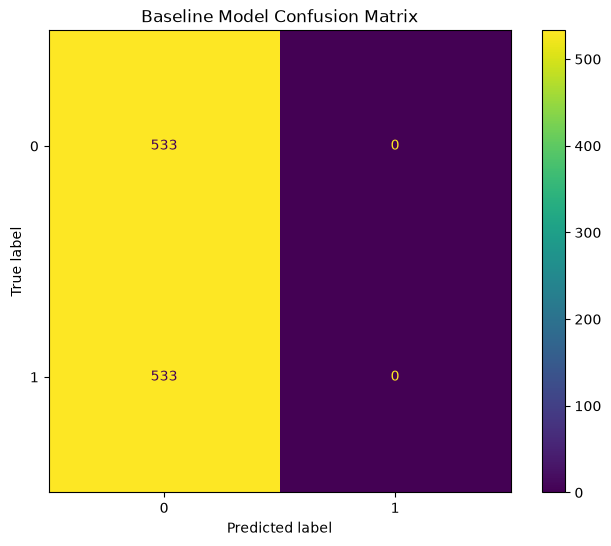

In [8]:
# Evaluate the model
metrics, report = evaluate_classifier(y_test, y_pred)

print("Baseline Model Metrics:")

for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value:.2f}")

confusion_matrix = plot_confusion_matrix("Baseline Model", y_test, y_pred)


In [9]:
# Add the results to a DataFrame for comparison with other models
results = []
results.append({
    "model": "Majority Class Baseline",
    **metrics,
})

benchmark_df = pd.DataFrame(results)
benchmark_df

,model,accuracy,precision,recall,f1
0,Majority Class Baseline,0.5,0.0,0.0,0.0


The majority-class baseline achieved an accuracy of 50%, which is expected given the balanced class distribution of the Rotten Tomatoes dataset. As the model always predicts the majority class, it fails to calculate precision, recall, and F1-score resulting in 0 for these metrics. This baseline establishes the minimum level of performance that any meaningful classifier should exceed.

# 3- Train the Bag of Words model

In [10]:
from src.models.bow import BagOfWordsClassifier


In [11]:
# Train the Bag of Words Classifier
bow = BagOfWordsClassifier()

bow.fit(X_train, y_train)

y_pred_bow = bow.predict(X_test)

# Evaluate the Bag of Words model
metrics_bow, report_bow = evaluate_classifier(y_test, y_pred_bow)

print("Bag-of-Words + Logistic Regression:")

for metric_name, metric_value in metrics_bow.items():
    print(f"{metric_name}: {metric_value:.2f}")
    

Bag-of-Words + Logistic Regression:
accuracy: 0.77
precision: 0.77
recall: 0.76
f1: 0.77


In [12]:
report_bow

{'negative': {'precision': 0.7652495378927912,
  'recall': 0.776735459662289,
  'f1-score': 0.770949720670391,
  'support': 533.0},
 'positive': {'precision': 0.7733333333333333,
  'recall': 0.7617260787992496,
  'f1-score': 0.7674858223062382,
  'support': 533.0},
 'accuracy': 0.7692307692307693,
 'macro avg': {'precision': 0.7692914356130622,
  'recall': 0.7692307692307693,
  'f1-score': 0.7692177714883146,
  'support': 1066.0},
 'weighted avg': {'precision': 0.7692914356130622,
  'recall': 0.7692307692307693,
  'f1-score': 0.7692177714883146,
  'support': 1066.0}}

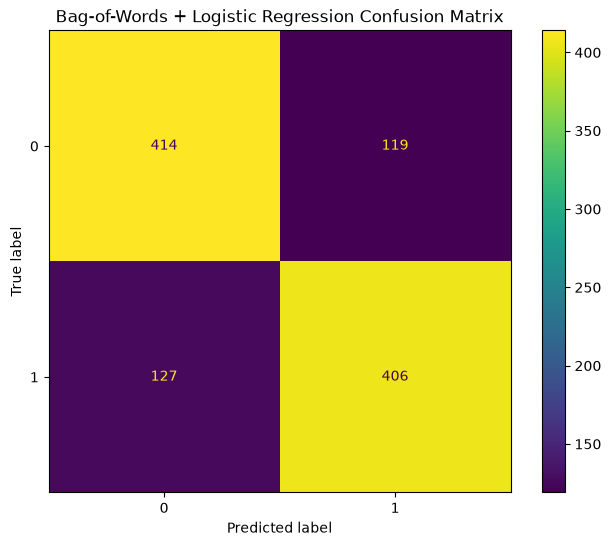

In [13]:
# Confiusion matrix for Bag of Words model
plot_confusion_matrix(
    "Bag-of-Words + Logistic Regression",
    y_test,
    y_pred_bow
)

plt.show()

In [14]:
# Append the Bag of Words model results to the benchmark DataFrame

results.append({
    "model": "Bag-of-Words + Logistic Regression",
    **metrics_bow,
})

benchmark_df = pd.DataFrame(results)
benchmark_df

,model,accuracy,precision,recall,f1
0,Majority Class Baseline,0.500000,0.000000,0.000000,0.000000
1,Bag-of-Words + Logistic Regression,0.769231,0.773333,0.761726,0.767486
